# Litio para baterías sin tostar la roca

Para sacar litio de su mineral más abundante hay que cocinarlo a más de 1.000 °C, gastar reactivos, y dejar residuos. Un equipo del MIT y Rock Zero acaba de demostrar que se puede hacer a menos de 100 °C, en agua, con un reactivo que se regenera. Y los 3 productos del proceso son vendibles.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Mowbray et al. (2026), *Valorization of lithium hardrock concentrates into battery raw materials and commodity products*, **Science**.

**DOI:** [10.1126/science.aec4652](https://doi.org/10.1126/science.aec4652)

[![Abrir en Colab]( https://colab.research.google.com/assets/colab-badge.svg )](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-29-spodumene-litio-bajo-temperatura/notebook.ipynb)

> 🎥 Video del paper: *pendiente — este notebook se publica antes del corto del canal*.

## De dónde viene el litio

Hay dos formas de obtener litio para baterías. Una es bombear salmuera de salares (Atacama, Salar de Uyuni) y dejar que el sol evapore el agua durante meses. La otra es romper rocas con espodumeno (LiAl(SiO₃)₂), un mineral que carga ~6,8% de óxido de litio (Li₂O).

La ruta de la roca es la que crece más rápido — pero también la más cara. Hay que tostar el concentrado a temperaturas mayores a 1.000 °C para abrir la estructura del cristal, después atacarla con ácido sulfúrico concentrado, y al final queda un residuo sólido difícil de vender (~7 toneladas por tonelada de litio).

Este paper plantea otra ruta: usar fluoruro de amonio (NH₄F) en agua, a menos de 100 °C, en un circuito cerrado que regenera el reactivo. Veamos qué encontraron.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_NH4F_C = 85           # °C — temperatura proceso NH4F (acuoso, <100)
TEMP_INCUMBENTE_C = 1050   # °C — temperatura tostado convencional (>1000)
FUENTE = 'Fuente: Mowbray et al. (2026), Science · DOI 10.1126/science.aec4652 | Datos: Supplementary Materials (Tablas S1-S7)'
COLOR_NH4F = '#2563EB'         # azul CaM — proceso nuevo
COLOR_INCUMBENTE = '#DC2626'   # rojo — proceso convencional
COLOR_CONTEXTO = '#BBBBBB'     # gris — contexto histórico
COLOR_REFERENCIA = '#D97706'   # amber — línea de referencia

# Imports
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Cargar estilo CaM (local primero, GitHub raw como fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carpeta figuras
os.makedirs('figuras', exist_ok=True)

# Carga de datos
yields = pd.read_csv('datos/yields_experimento_principal.csv')
generality = pd.read_csv('datos/process_generality.csv')
thermo = pd.read_csv('datos/reaction_thermodynamics.csv')
tea = pd.read_csv('datos/tea_parameters.csv')
feedstock = pd.read_csv('datos/feedstock_composition.csv')
alumina = pd.read_csv('datos/alumina_purity.csv')
sensitivity = pd.read_csv('datos/sensitivity_inputs.csv')

print(f'Yields del experimento principal: {len(yields)} productos/intermediarios')
print(f'Muestras testeadas para generalidad: {len(generality)} de {generality.origen.nunique()} países')
print(f'Reacciones balanceadas en el closed-loop: {len(thermo)}')
print(f'  exotérmicas: {(thermo.tipo == "exotermica").sum()}, endotérmicas: {(thermo.tipo == "endotermica").sum()}')
print(f'Composición elemental del feedstock: {len(feedstock)} elementos analizados')

Yields del experimento principal: 6 productos/intermediarios
Muestras testeadas para generalidad: 17 de 4 países
Reacciones balanceadas en el closed-loop: 11
  exotérmicas: 8, endotérmicas: 3
Composición elemental del feedstock: 36 elementos analizados


## Aquí está la diferencia.

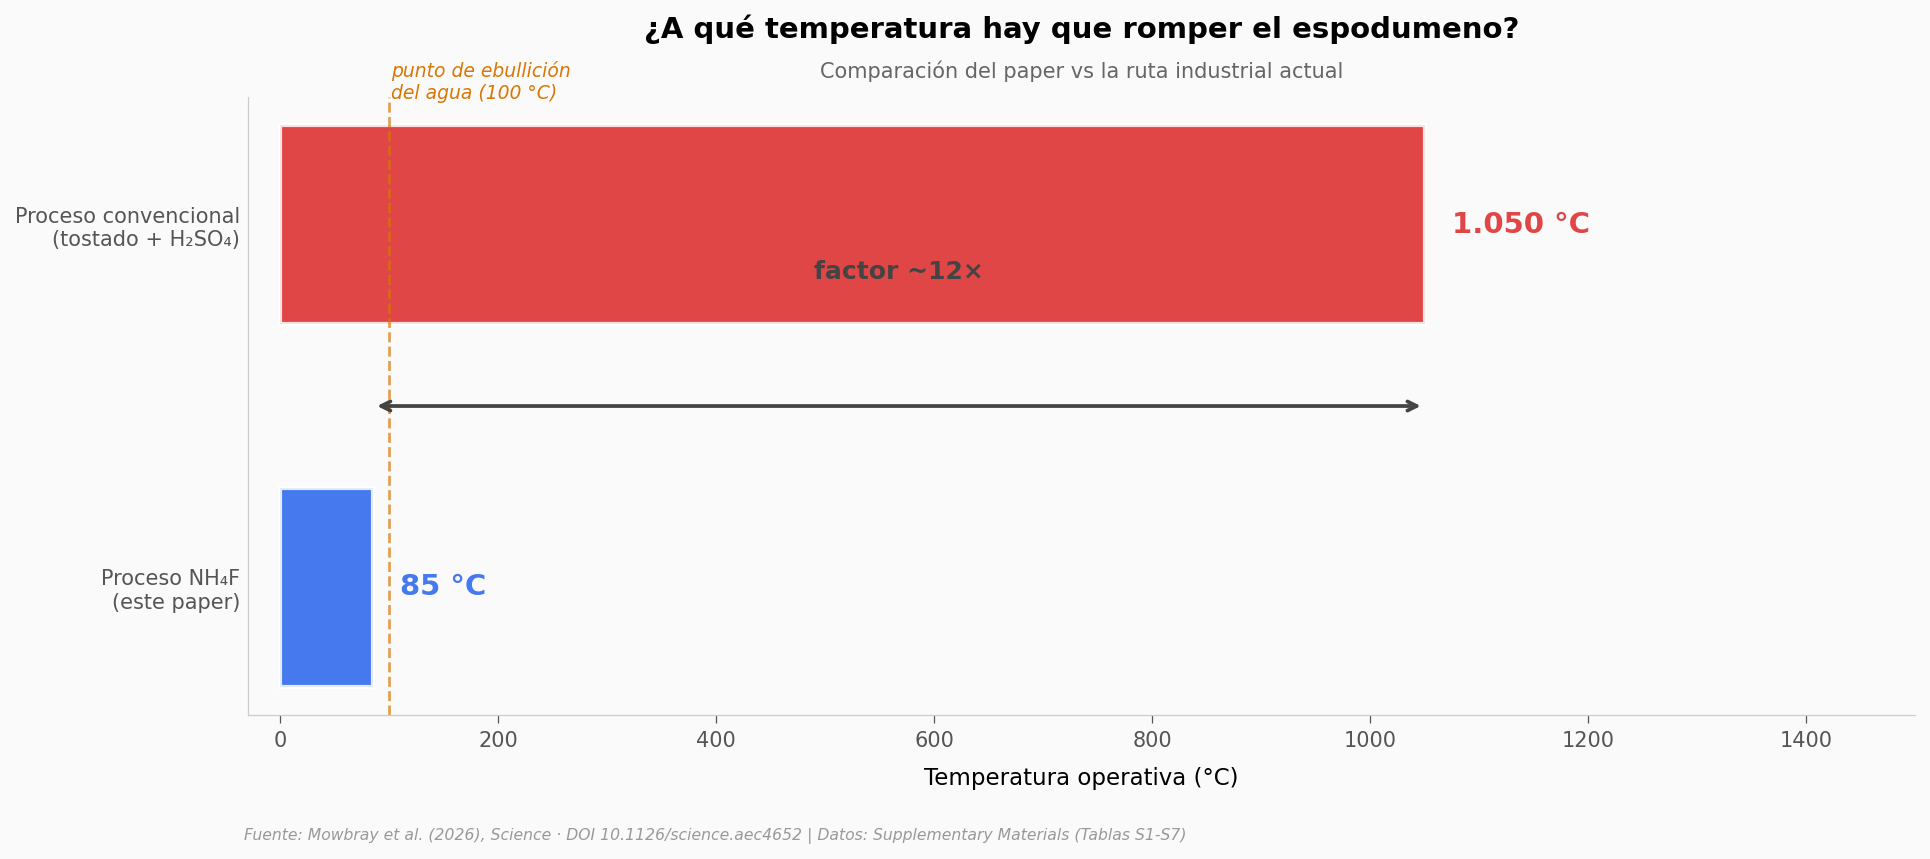

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

procesos = ['Proceso NH₄F\n(este paper)', 'Proceso convencional\n(tostado + H₂SO₄)']
temps = [TEMP_NH4F_C, TEMP_INCUMBENTE_C]
colores = [COLOR_NH4F, COLOR_INCUMBENTE]

bars = ax.barh(procesos, temps, color=colores, alpha=0.85,
               edgecolor='white', linewidth=2, height=0.55)

# Etiquetas numéricas al final de cada barra
for bar, val in zip(bars, temps):
    ax.text(val + 25, bar.get_y() + bar.get_height()/2,
            f'{val:,} °C'.replace(',', '.'),
            fontsize=14, fontweight='bold',
            va='center', ha='left',
            color=bar.get_facecolor())

# Anotación factor 10×
ax.annotate('', xy=(TEMP_INCUMBENTE_C, 0.5), xytext=(TEMP_NH4F_C, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.8))
ax.text((TEMP_NH4F_C + TEMP_INCUMBENTE_C) / 2, 0.85,
        'factor ~12×', fontsize=12, fontweight='bold',
        color='#444444', ha='center')

# Línea vertical del punto de ebullición del agua
ax.axvline(x=100, color=COLOR_REFERENCIA, linewidth=1.3, linestyle='--', alpha=0.7)
ax.text(102, 1.45, 'punto de ebullición\ndel agua (100 °C)',
        fontsize=9, color=COLOR_REFERENCIA, va='top', style='italic')

ax.set_xlim(-30, 1500)
ax.set_xlabel('Temperatura operativa (°C)', fontsize=11)
ax.set_title('¿A qué temperatura hay que romper el espodumeno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación del paper vs la ruta industrial actual',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Limpiar yticks
ax.tick_params(axis='y', length=0)
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/temperatura_comparada.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia no es de grado, es categórica. Por debajo del punto de ebullición del agua, el proceso es **hidrometalurgia** — química acuosa, reactores estándar, sin hornos de arco. Por encima de 1.000 °C, es **pirometalurgia** — calcinadores rotatorios, refractarios costosos, energía concentrada.

Esa frontera no es decorativa. Marca el costo del capital, el consumo eléctrico, y dónde puede instalarse la planta. Un proceso a <100 °C cabe físicamente en lugares donde un horno a 1.050 °C no es viable.

## ¿Funciona con cualquier roca?

Una cosa es que el proceso funcione con el concentrado de espodumeno australiano grado A. Otra muy distinta es que funcione con minerales de baja ley, tailings de beneficiación, o lepidolita.

El equipo testeó 17 muestras de Australia, Estados Unidos, Brasil y Canadá, con grados de Li₂O entre 0,8% y 7,2%. Veamos qué tan robusto resultó el rendimiento.

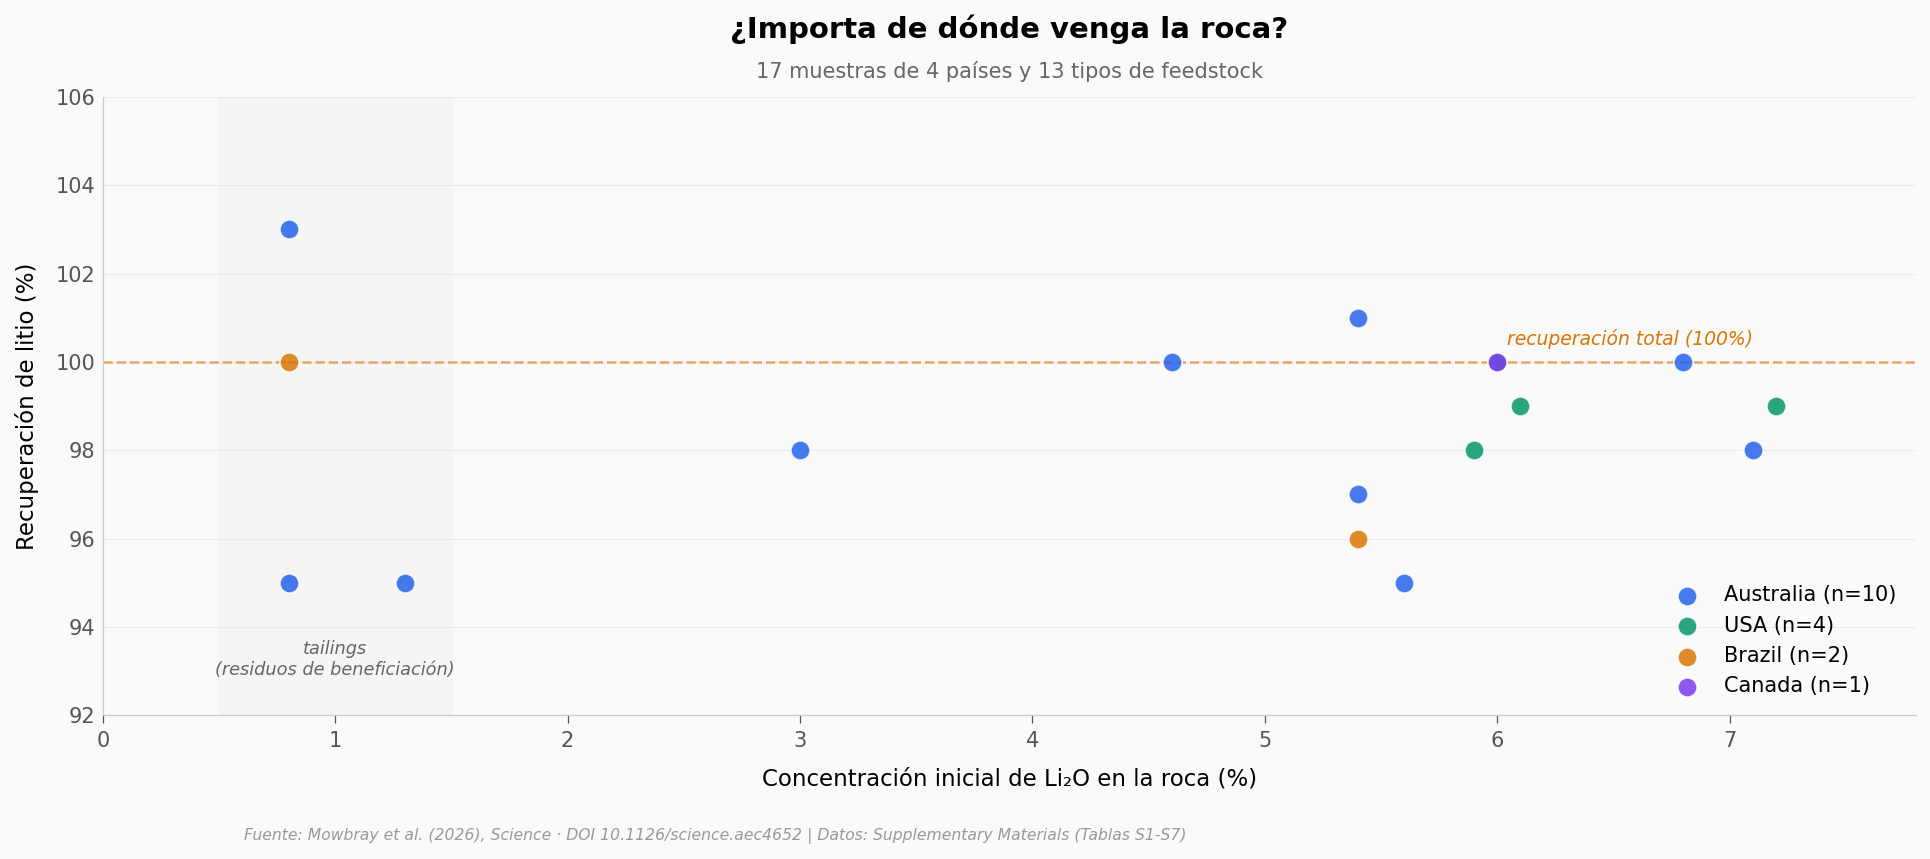

Recuperación de litio — mediana: 99.0%
Rango: 95% – 103%
Muestras con Li yield ≥95%: 17/17


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Color por país
paises_color = {
    'Australia': '#2563EB',
    'USA': '#059669',
    'Brazil': '#D97706',
    'Canada': '#7C3AED',
}

# Reproducible jitter en X (Li2O grade ya da espacio, no necesita)
np.random.seed(42)

for pais, color in paises_color.items():
    sub = generality[generality.origen == pais]
    ax.scatter(sub.Li2O_grade_pct, sub.Li_yield_pct,
               color=color, s=85, alpha=0.85,
               edgecolors='white', linewidths=0.8, zorder=5,
               label=f'{pais} (n={len(sub)})')

# Línea de referencia 100%
ax.axhline(y=100, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(7.1, 100.3, 'recuperación total (100%)',
        fontsize=9, color=COLOR_REFERENCIA, ha='right', va='bottom', style='italic')

# Anotación del rango de tailings
ax.axvspan(0.5, 1.5, alpha=0.08, color=COLOR_CONTEXTO)
ax.text(1.0, 93.7, 'tailings\n(residuos de beneficiación)',
        fontsize=8.5, color='#666666', ha='center', va='top', style='italic')

ax.set_xlabel('Concentración inicial de Li₂O en la roca (%)', fontsize=11)
ax.set_ylabel('Recuperación de litio (%)', fontsize=11)
ax.set_ylim(92, 106)
ax.set_xlim(0, 7.8)

ax.set_title('¿Importa de dónde venga la roca?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '17 muestras de 4 países y 13 tipos de feedstock',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/generalidad_origen.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticos
print(f'Recuperación de litio — mediana: {generality.Li_yield_pct.median():.1f}%')
print(f'Rango: {generality.Li_yield_pct.min():.0f}% – {generality.Li_yield_pct.max():.0f}%')
print(f'Muestras con Li yield ≥95%: {(generality.Li_yield_pct >= 95).sum()}/{len(generality)}')

## ¿Por qué funciona a baja temperatura?

La respuesta corta: porque el espodumeno reacciona con NH₄HF₂ liberando muchísima energía. La digestión inicial — ese único paso donde el mineral se rompe — suelta del orden de 8.876 kJ por mol de reacción.

Eso significa que el proceso, en balance, no necesita calor externo. Lo libera. El equipo balanceó las 11 reacciones del circuito cerrado y midió cuántas son exotérmicas y cuántas endotérmicas.

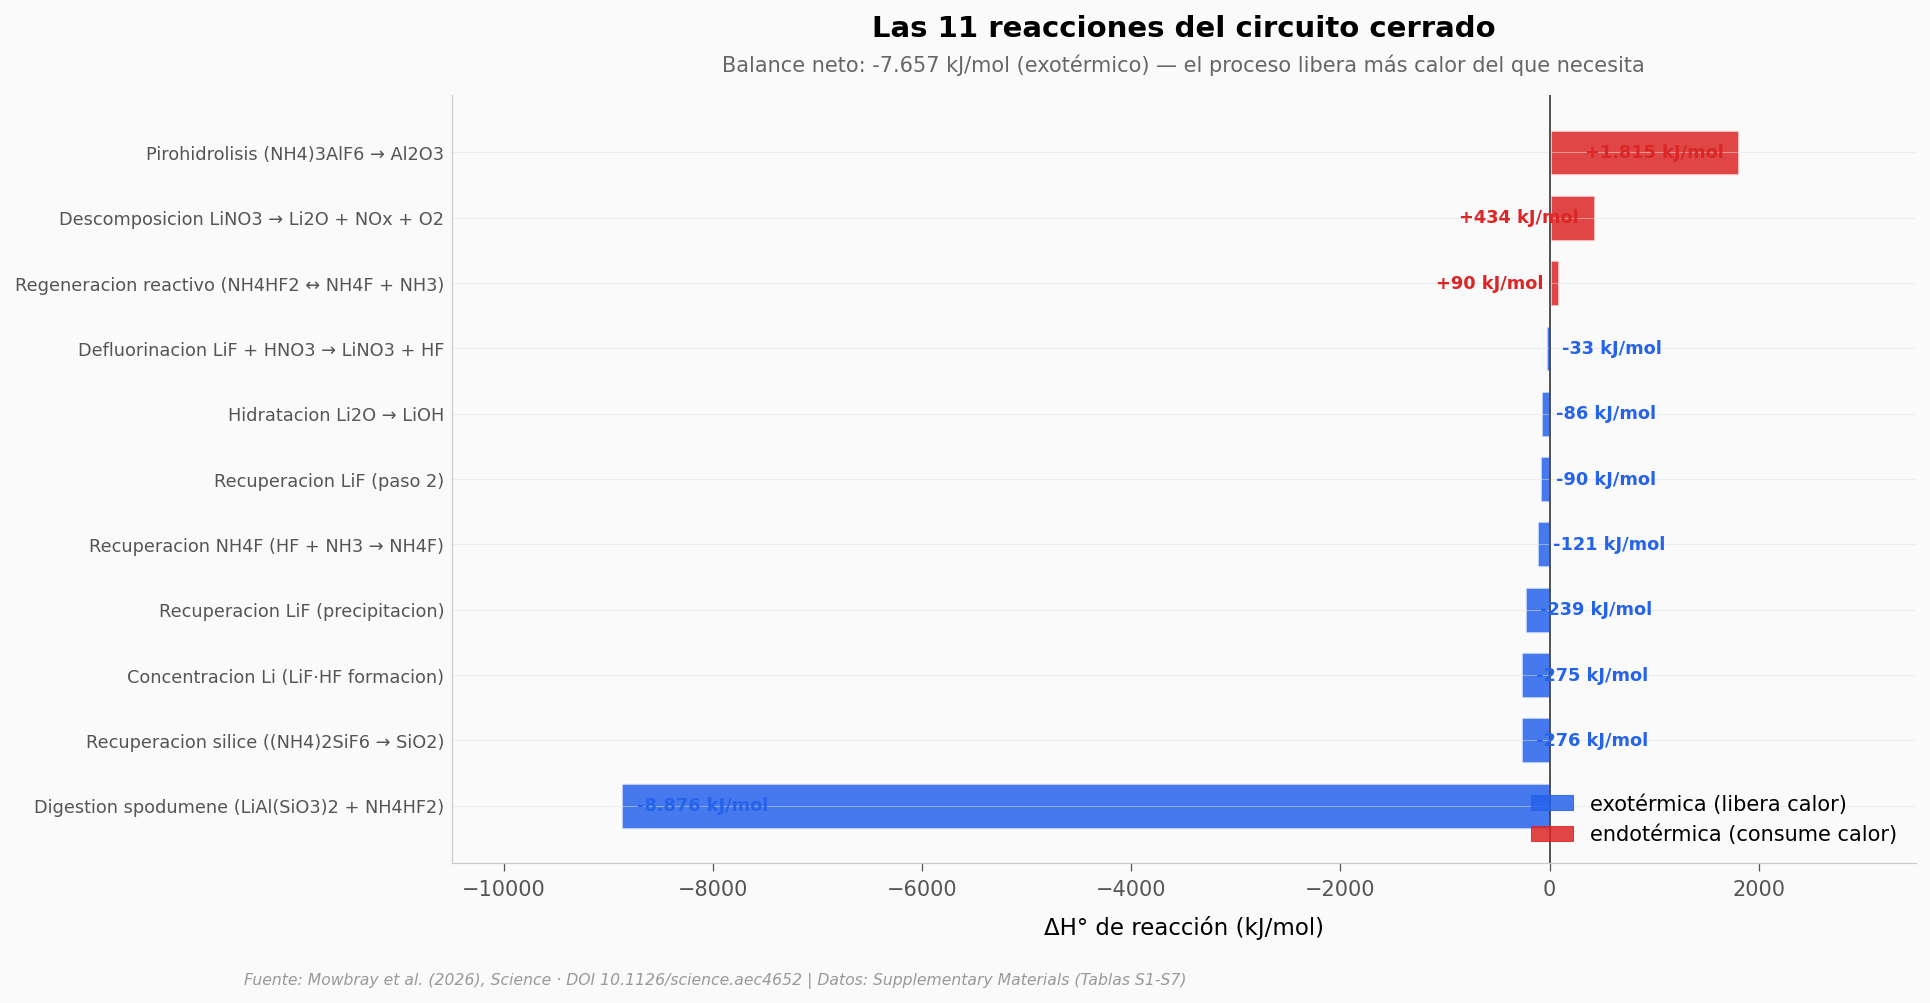

Reacción más exotérmica: Digestion spodumene (LiAl(SiO3)2 + NH4HF2)
  ΔH = -8.876 kJ/mol
Reacción más endotérmica: Pirohidrolisis (NH4)3AlF6 → Al2O3
  ΔH = 1.815 kJ/mol
Balance neto: -7.657 kJ/mol


In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))

# Ordenar por valor absoluto descendente para impacto visual
thermo_sorted = thermo.sort_values('delta_H_kJ_mol').reset_index(drop=True)

# Colores: exo en azul CaM, endo en rojo
colores_termo = [COLOR_NH4F if t == 'exotermica' else COLOR_INCUMBENTE
                 for t in thermo_sorted.tipo]

# Etiquetas cortas para el eje Y
ax.barh(range(len(thermo_sorted)), thermo_sorted.delta_H_kJ_mol,
        color=colores_termo, alpha=0.85,
        edgecolor='white', linewidth=1.2, height=0.7)

ax.set_yticks(range(len(thermo_sorted)))
ax.set_yticklabels(thermo_sorted.reaccion_corta, fontsize=8.5)
ax.axvline(x=0, color='#333333', linewidth=0.8)

# Anotaciones para los extremos
for i, row in thermo_sorted.iterrows():
    val = row.delta_H_kJ_mol
    offset = 150 if val < 0 else -150
    ha = 'left' if val < 0 else 'right'
    txt_color = COLOR_NH4F if val < 0 else COLOR_INCUMBENTE
    ax.text(val + offset, i, f'{int(val):+,} kJ/mol'.replace(',', '.'),
            fontsize=8.5, va='center', ha=ha, color=txt_color, fontweight='bold')

# Balance neto en el subtítulo
balance_neto = thermo.delta_H_kJ_mol.sum()
ax.set_title('Las 11 reacciones del circuito cerrado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Balance neto: {int(balance_neto):+,} kJ/mol (exotérmico) — el proceso libera más calor del que necesita'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('ΔH° de reacción (kJ/mol)', fontsize=11)
ax.set_xlim(-10500, 3500)

# Leyenda inline
exo_patch = mpatches.Patch(color=COLOR_NH4F, alpha=0.85, label='exotérmica (libera calor)')
endo_patch = mpatches.Patch(color=COLOR_INCUMBENTE, alpha=0.85, label='endotérmica (consume calor)')
ax.legend(handles=[exo_patch, endo_patch], loc='lower right', fontsize=10, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/termodinamica_cascada.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Reacción más exotérmica: {thermo.loc[thermo.delta_H_kJ_mol.idxmin(), "reaccion_corta"]}')
print(f'  ΔH = {thermo.delta_H_kJ_mol.min():,.0f} kJ/mol'.replace(',', '.'))
print(f'Reacción más endotérmica: {thermo.loc[thermo.delta_H_kJ_mol.idxmax(), "reaccion_corta"]}')
print(f'  ΔH = {thermo.delta_H_kJ_mol.max():,.0f} kJ/mol'.replace(',', '.'))
print(f'Balance neto: {balance_neto:,.0f} kJ/mol'.replace(',', '.'))

## ¿Qué tan robusto es ese 99%?

Una mediana de 99% suena bien, pero la pregunta importante es: ¿con qué frecuencia se sale del rango? Si la cola izquierda baja a 70%, el proceso no escala. Si está concentrada cerca del techo, sí.

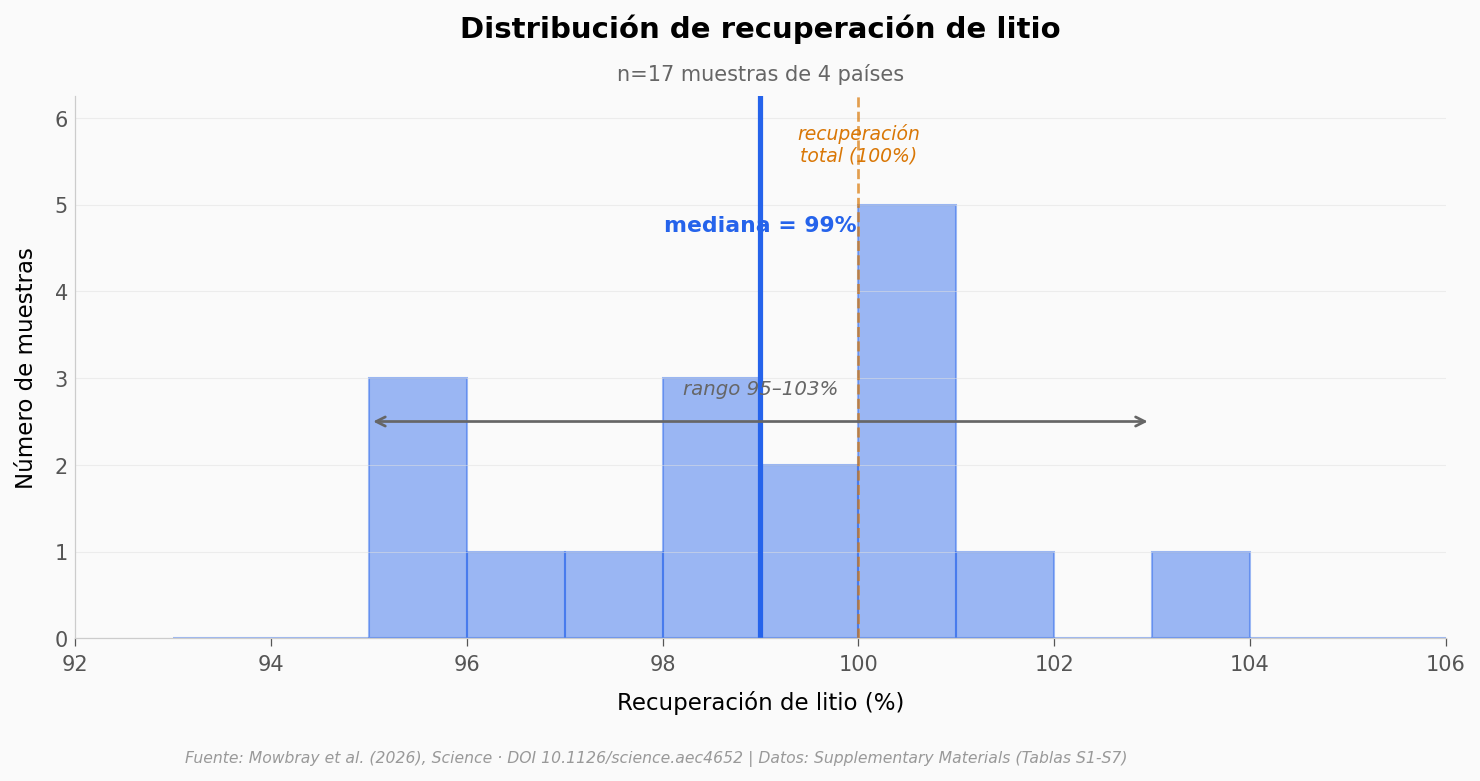

Recuperación mediana: 99.0%
Recuperación media: 98.5%
Rango: 95% – 103%
Muestras ≥95%: 17/17 (100%)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

li_yields = generality.Li_yield_pct.values
mediana = np.median(li_yields)
media = np.mean(li_yields)

# Bins ajustados al rango observado
bins = np.arange(93, 107, 1)
n, bins_out, patches = ax.hist(li_yields, bins=bins, color=COLOR_NH4F, alpha=0.45,
                                edgecolor=COLOR_NH4F, linewidth=1)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Líneas verticales
ax.axvline(x=100, color=COLOR_REFERENCIA, linewidth=1.3, linestyle='--', alpha=0.7)
ax.axvline(x=mediana, color=COLOR_NH4F, linewidth=2.5)

# Anotaciones
ax.text(100, y_max*0.95, 'recuperación\ntotal (100%)',
        fontsize=9, color=COLOR_REFERENCIA, ha='center', va='top', style='italic')
ax.text(mediana, y_max*0.78, f'mediana = {mediana:.0f}%',
        fontsize=10.5, color=COLOR_NH4F, ha='center', va='top', fontweight='bold')

# Flecha rango
rango_min, rango_max = li_yields.min(), li_yields.max()
ax.annotate('', xy=(rango_max, y_max*0.4), xytext=(rango_min, y_max*0.4),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.3))
ax.text((rango_min + rango_max)/2, y_max*0.45,
        f'rango {rango_min:.0f}–{rango_max:.0f}%',
        fontsize=9.5, color='#666666', ha='center', style='italic')

ax.set_xlabel('Recuperación de litio (%)', fontsize=11)
ax.set_ylabel('Número de muestras', fontsize=11)
ax.set_xlim(92, 106)

ax.set_title('Distribución de recuperación de litio',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'n={len(li_yields)} muestras de 4 países',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distribucion_yields.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Recuperación mediana: {mediana:.1f}%')
print(f'Recuperación media: {media:.1f}%')
print(f'Rango: {rango_min:.0f}% – {rango_max:.0f}%')
print(f'Muestras ≥95%: {(li_yields >= 95).sum()}/{len(li_yields)} ({100*(li_yields >= 95).sum()/len(li_yields):.0f}%)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El proceso opera a menos de 100 °C vs >1.000 °C del incumbente | ✅ | Tabla S5: 100 °C vs 1.000 °C — diferencia categórica entre hidro y pirometalurgia |
| Recuperación de litio mediana del 99% en 17 muestras de 4 países | ✅ | Tabla S7: n=17, mediana 99%, rango 95–103%, 17/17 ≥95% |
| Pureza del Li₂CO₃ producido equivale o supera al estándar comercial | ✅ | 99 ± 0,6% vs Alfa Aesar 99,999% (medido en 98,9%) — diferencia dentro de incertidumbre |
| Balance termodinámico neto exotérmico explica baja temperatura | ✅ | 11 reacciones balanceadas: 8 exo + 3 endo, ΔH neto −7.657 kJ/mol |
| El reactivo (NH₄F) se regenera en el circuito cerrado | ✅ | Tabla S4: paso 1 y paso 10 cierran el ciclo del NH₄F |
| Producción de 3 commodities (Li₂CO₃, Al₂O₃, SiO₂) en un solo proceso | ✅ | Yields experimentales: 100% Si, 97% Al(NH₄)₃F₆, 99% Li₂CO₃ |
| El proceso podría reducir el costo de producción de litio en más del 40% | ⚠️ | El paper lo enmarca como proyección del análisis técnico-económico (*may reduce*) — no medición de planta construida |
| El proceso habilitaría paridad de costo con salmueras | ⚠️ | Mismo origen TEA — sin planta piloto que confirme |

> **Limitaciones del análisis:**
> - El experimento principal corre a escala de laboratorio (~30 kg de feedstock). No hay planta piloto que valide el escalamiento a 30.000 toneladas/año, que es la escala asumida en el TEA.
> - Los yields superiores a 100% que aparecen en algunas muestras (Al hasta 132%, Si hasta 103%) se deben a inhomogeneidad del feedstock en muestras de bajo grado o partícula gruesa — el paper lo anota explícitamente como artefacto de muestreo, no como exceso real.
> - La reducción de costo >40% asume precio del NH₄F de 400 USD/tonelada con pérdida del 1% por ciclo. El análisis de sensibilidad muestra que si el reactivo cuesta 1.500 USD/t o la pérdida sube al 5%, los márgenes se comprimen mucho.
> - La pureza del Al₂O₃ se reporta como cota inferior (98,58%) porque 12 de 39 óxidos quedaron por debajo del límite de detección — el valor real podría ser mayor.

## Ahora tú

Tres preguntas que el notebook te deja a mano para explorar con los datos cargados:

1. **¿El proceso funciona igual con tailings que con concentrados premium?** Pista: filtra `generality` por `Li2O_grade_pct < 2` y compara la mediana de `Li_yield_pct` con la del subconjunto `Li2O_grade_pct > 5`.

2. **¿Cuál es el paso que más calor libera por tonelada de feedstock?** Pista: en `thermo`, sumá `delta_H_kJ_mol` por `etapa` (procesado_silicato, upgrading_litio, upgrading_aluminio).

3. **¿Qué tan sensible es el caso económico al precio del NH₄F?** Pista: en `sensitivity`, el `costo_nh4f` oscila entre 500 y 1.500 USD/tonelada — calculá el cambio porcentual respecto al mediano (400).

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿el proceso funciona igual con tailings que con concentrados premium?

tailings = generality[generality.Li2O_grade_pct < 2]
premium = generality[generality.Li2O_grade_pct > 5]

print('Tailings (Li₂O < 2%):')
print(f'  n = {len(tailings)}')
print(f'  recuperación Li mediana = {tailings.Li_yield_pct.median():.1f}%')
print(f'  rango: {tailings.Li_yield_pct.min():.0f}% – {tailings.Li_yield_pct.max():.0f}%')
print()
print('Premium (Li₂O > 5%):')
print(f'  n = {len(premium)}')
print(f'  recuperación Li mediana = {premium.Li_yield_pct.median():.1f}%')
print(f'  rango: {premium.Li_yield_pct.min():.0f}% – {premium.Li_yield_pct.max():.0f}%')
print()
print(f'Diferencia de medianas: {tailings.Li_yield_pct.median() - premium.Li_yield_pct.median():+.1f} pp')

Tailings (Li₂O < 2%):
  n = 4
  recuperación Li mediana = 97.5%
  rango: 95% – 103%

Premium (Li₂O > 5%):
  n = 11
  recuperación Li mediana = 99.0%
  rango: 95% – 101%

Diferencia de medianas: -1.5 pp


## Fuentes

**Paper**: [Valorization of lithium hardrock concentrates into battery raw materials and commodity products](https://doi.org/10.1126/science.aec4652)  
*Science, 2026-05-28 · paywall*

**Supplementary Material**: [Supplementary Materials for: Valorization of lithium hardrock concentrates — Tables S1-S7, Figs S1-S29](https://www.science.org/doi/suppl/10.1126/science.aec4652/suppl_file/science.aec4652_sm.pdf)  
*Science (Supplementary Materials), 2026-05-28 · PDF abierto, 49 páginas (Tablas S1-S7 + Figs S1-S29)*

*17 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos originales:** Supplementary Materials del paper (Tablas S1–S7, distribuidas como PDF abierto por Science).

**Licencia:** los datos son de uso académico bajo la política editorial de Science. El notebook (código y narrativa) es de Ciencia a Mordiscos, bajo MIT.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)